In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


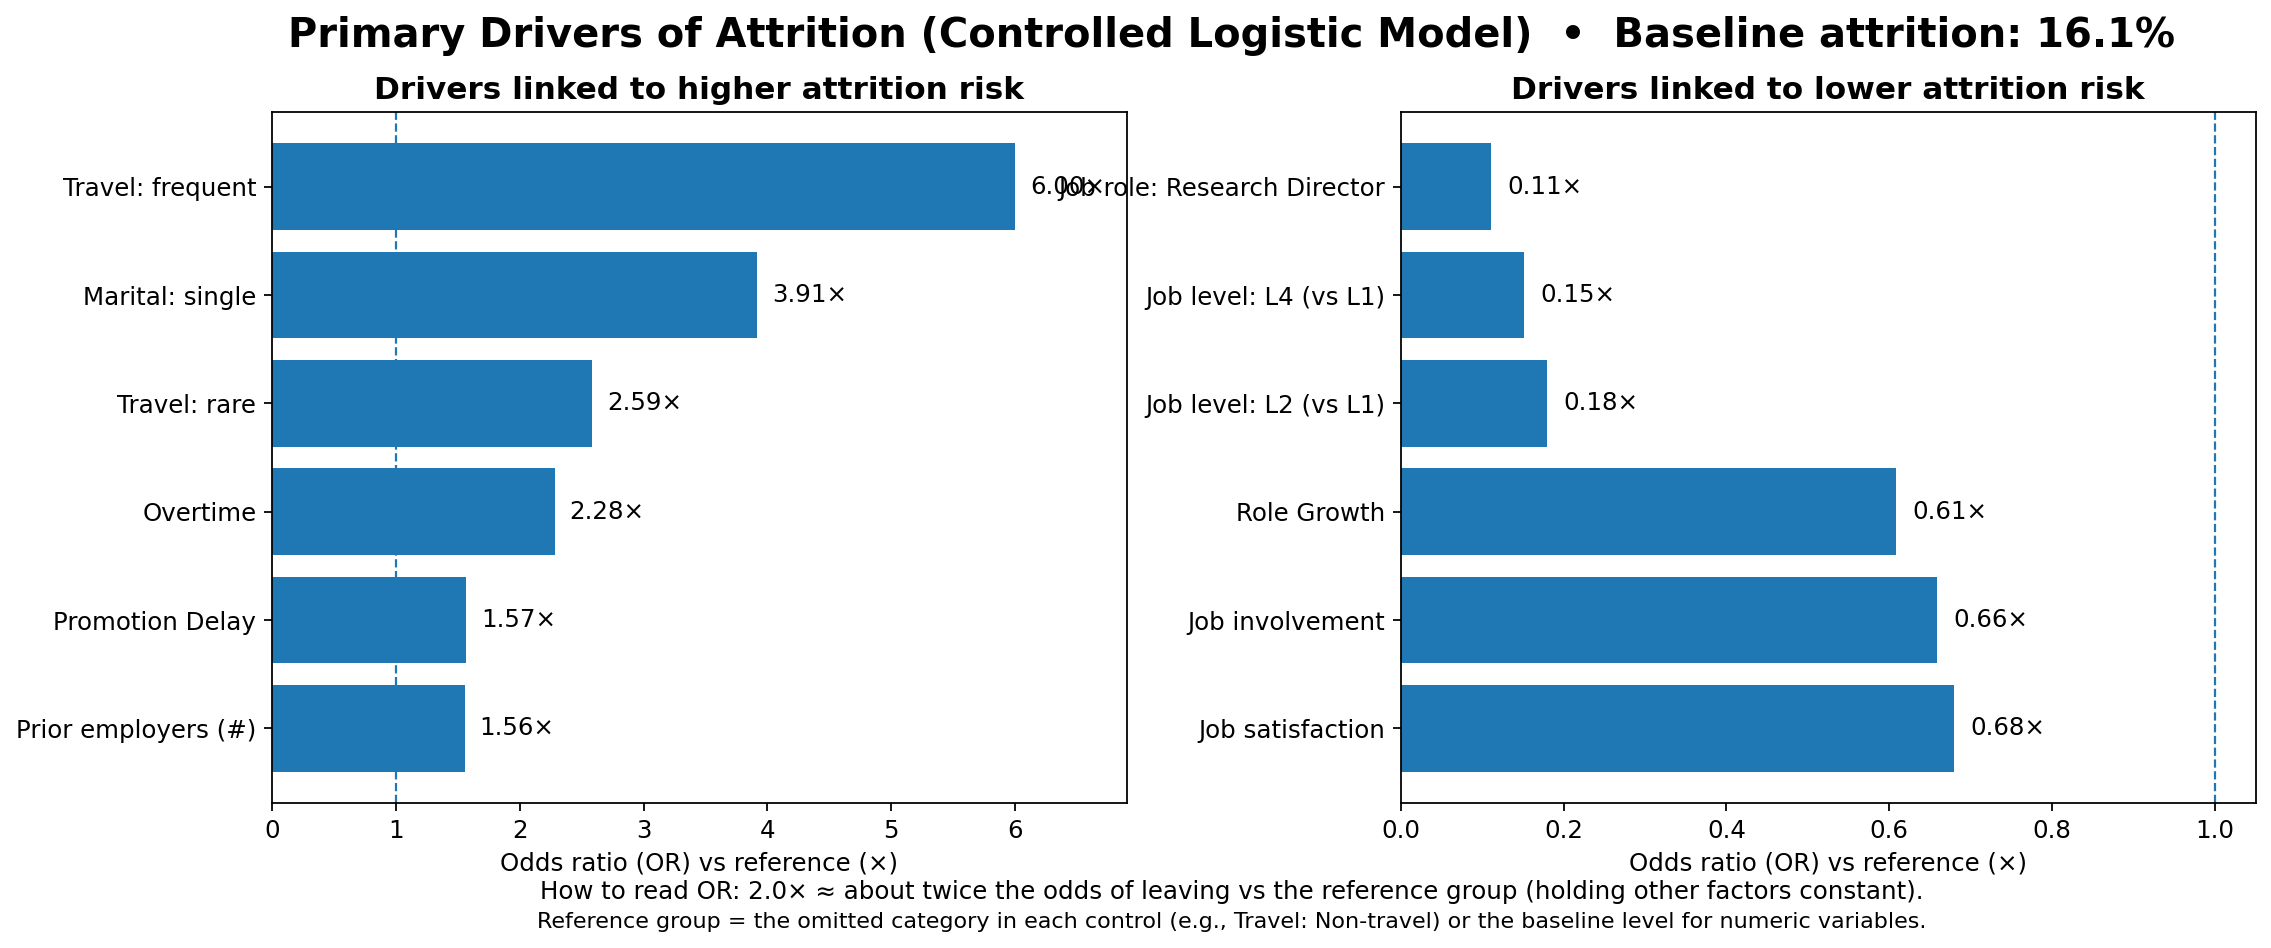

Saved: /content/drive/MyDrive/550 Project/Regression Versions/simon/viz_step2_primary_drivers.png
Saved: /content/drive/MyDrive/550 Project/Regression Versions/simon/persona_table_step3.csv


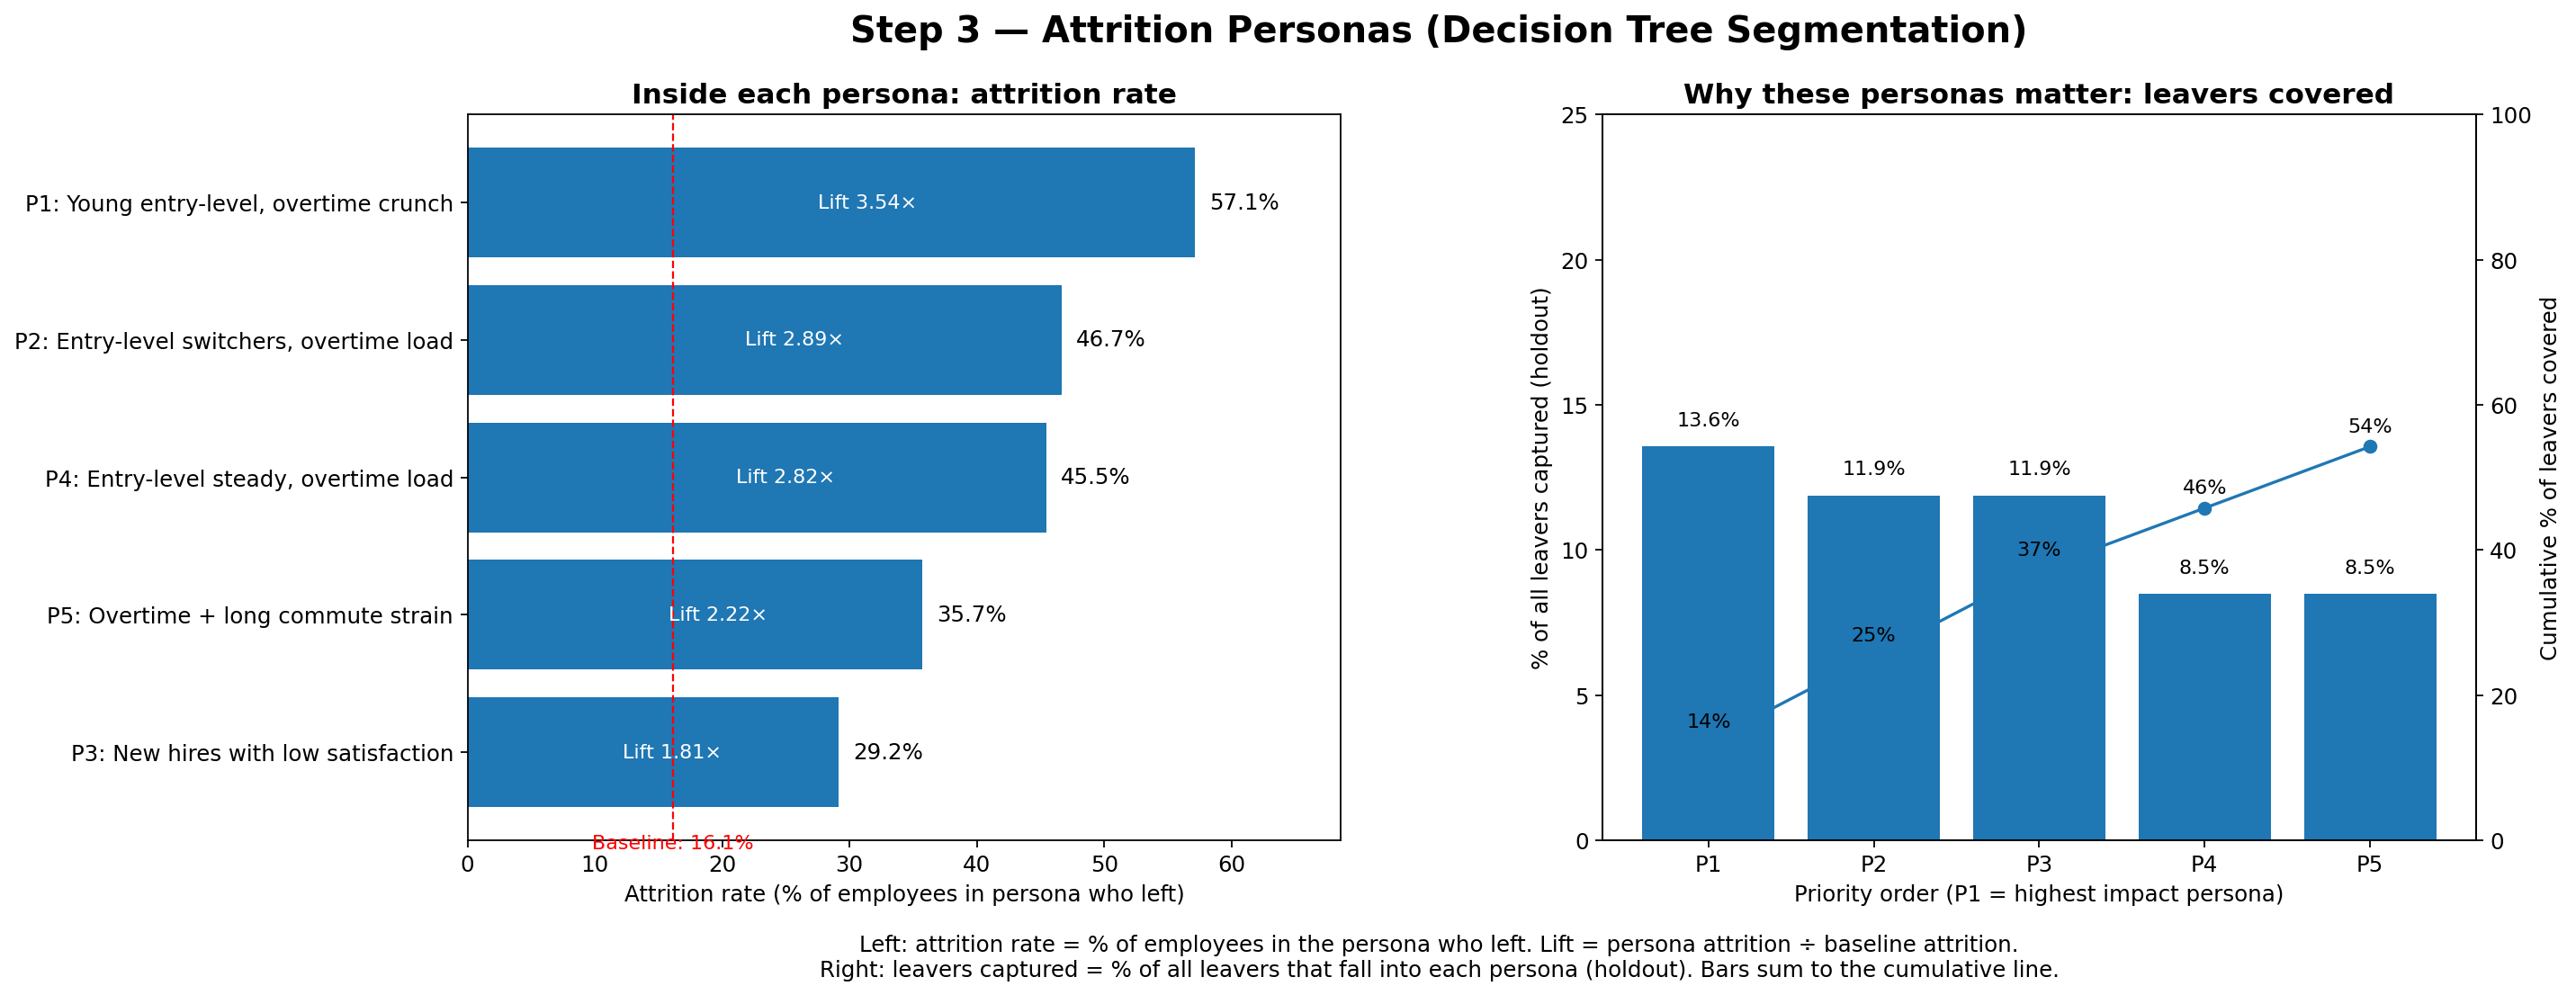

Saved: /content/drive/MyDrive/550 Project/Regression Versions/simon/viz_step3_personas.png


,Persona ID,Persona,Definition,Employees (holdout),Leavers captured (holdout),Lift vs baseline
0,P1,"Young entry-level, overtime crunch",Overtime = Yes • Job level = Entry (L1) • Age ...,14,13.6%,3.54×
1,P2,"Entry-level switchers, overtime load",Overtime = Yes • Job level = Entry (L1) • Age ...,15,11.9%,2.89×
2,P3,New hires with low satisfaction,Overtime = No • Early Tenure (<3y) = Yes • Age...,24,11.9%,1.81×
3,P4,"Entry-level steady, overtime load",Overtime = Yes • Job level = Entry (L1) • Age ...,11,8.5%,2.82×
4,P5,Overtime + long commute strain,Overtime = Yes • Job level ≠ Entry (L1) • Mari...,14,8.5%,2.22×


In [6]:
# ============================================================
# Executive-ready visuals (Step 2 Logistic + Step 3 Personas)
# Reads 4 outputs in your Simon folder and saves PNGs there.
# ============================================================

import os, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0) CONFIG — set your folder
# -----------------------------
BASE_DIR = "/content/drive/MyDrive/550 Project/Regression Versions/simon"  # <- your Simon folder

PATH_DRIVER = os.path.join(BASE_DIR, "logistic_regression_driver_terms.csv")
PATH_META   = os.path.join(BASE_DIR, "logistic_regression_model_meta.json")
PATH_SEG    = os.path.join(BASE_DIR, "risk_profile_segments_tree.csv")
PATH_SEG_HI = os.path.join(BASE_DIR, "risk_profile_segments_tree_high_risk.csv")

OUT_STEP2 = os.path.join(BASE_DIR, "viz_step2_primary_drivers.png")
OUT_STEP3 = os.path.join(BASE_DIR, "viz_step3_personas.png")
OUT_TABLE = os.path.join(BASE_DIR, "persona_table_step3.csv")

# -----------------------------
# Helpers
# -----------------------------
def _safe_read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return {}

def _pct(x):
    return f"{x*100:.1f}%" if pd.notna(x) else ""

def _clamp01(x):
    return max(0.0, min(1.0, float(x)))

def clean_term_name(term: str) -> str:
    """Make model term names business-friendly."""
    if term is None:
        return ""
    t = str(term)

    # common dummies
    t = t.replace("BusinessTravel_Travel_Frequently", "Travel: frequent")
    t = t.replace("BusinessTravel_Travel_Rarely", "Travel: rare")
    t = t.replace("MaritalStatus_Single", "Marital: single")
    t = t.replace("Gender_Male", "Gender: male")
    t = t.replace("OverTimeFlag", "Overtime")
    t = t.replace("NumCompaniesWorked", "Prior employers (#)")
    t = t.replace("YearsSinceLastPromotion", "Promotion delay")
    t = t.replace("DistanceFromHome", "Commute distance")
    t = t.replace("JobInvolvement", "Job involvement")
    t = t.replace("JobSatisfaction", "Job satisfaction")
    t = t.replace("YearsInCurrentRole", "Role growth")
    t = t.replace("Age", "Age")

    # job levels
    t = re.sub(r"JobLevel_2\b", "Job level: L2 (vs L1)", t)
    t = re.sub(r"JobLevel_3\b", "Job level: L3 (vs L1)", t)
    t = re.sub(r"JobLevel_4\b", "Job level: L4 (vs L1)", t)
    t = re.sub(r"JobLevel_5\b", "Job level: L5 (vs L1)", t)

    # job roles
    t = t.replace("JobRole_Research Director", "Job role: Research Director")
    t = t.replace("JobRole_Sales Executive", "Job role: Sales Executive")
    t = t.replace("JobRole_Sales Representative", "Job role: Sales Representative")
    t = t.replace("JobRole_Human Resources", "Job role: Human Resources")
    t = t.replace("Department_Research & Development", "Department: R&D")
    t = t.replace("Department_Sales", "Department: Sales")

    # clean underscores / casing leftovers
    t = t.replace("_", " ")
    t = re.sub(r"\s+", " ", t).strip()
    # soft title-case for readability (but keep acronyms)
    return t

def short_persona_name(pretty_rule: str) -> str:
    """Create a human nickname from the rule (business-friendly)."""
    r = str(pretty_rule)

    is_ot = ("OverTime = Yes" in r)
    is_entry = ("JobLevel = 1" in r)
    under30 = ("Age = Under 30" in r)
    age30p = ("Age ≠ Under 30" in r) or ("Age = 30-39" in r) or ("Age = 40-49" in r) or ("Age = 50+" in r)
    long_commute = ("Commute" in r and (">" in r))
    low_sat = ("JobSatisfaction" in r and ("≤" in r or "<=" in r))
    early_tenure = ("Early Tenure" in r and "= Yes" in r)
    many_prior = ("NumCompaniesWorked" in r and (">" in r))
    few_prior  = ("NumCompaniesWorked" in r and ("≤" in r or "<=" in r))

    # Priority: make names distinct and human
    if is_ot and is_entry and under30:
        return "Young entry-level, overtime crunch"
    if is_ot and is_entry and age30p and many_prior:
        return "Entry-level switchers, overtime load"
    if is_ot and is_entry and age30p and few_prior:
        return "Entry-level steady, overtime load"
    if (not is_ot) and early_tenure and low_sat:
        return "New hires with low satisfaction"
    if is_ot and (not is_entry) and long_commute:
        return "Overtime + long commute strain"
    if (not is_ot) and low_sat:
        return "Low satisfaction segment"
    if is_ot:
        return "Overtime-heavy group"
    return "Mixed-risk group"

def tidy_rule(rule: str) -> str:
    """Readable rule text for a table."""
    r = str(rule)
    r = r.replace("OverTime = Yes", "Overtime = Yes")
    r = r.replace("OverTime ≠ Yes", "Overtime = No")
    r = r.replace("JobLevel = 1", "Job level = Entry (L1)")
    r = r.replace("JobLevel ≠ 1", "Job level ≠ Entry (L1)")
    r = r.replace("MaritalStatus ≠ Single", "Marital ≠ Single")
    r = r.replace("MaritalStatus = Single", "Marital = Single")
    r = r.replace("BusinessTravel = Travel_Frequently", "Travel = Frequent")
    r = r.replace("BusinessTravel = Travel_Rarely", "Travel = Rare")
    r = r.replace("BusinessTravel ≠ Travel_Rarely", "Travel ≠ Rare")
    r = r.replace("NumCompaniesWorked", "Prior employers (#)")
    r = r.replace("DistanceFromHome", "Commute distance")
    r = r.replace("YearsSinceLastPromotion", "Promotion delay (years)")
    r = r.replace("YearsInCurrentRole", "Role growth (years in role)")
    r = re.sub(r"\s+", " ", r).strip()

    # Make AND separators nicer
    r = r.replace(" AND ", " • ")
    return r

# -----------------------------
# 1) Load files
# -----------------------------
meta = _safe_read_json(PATH_META)

drivers = pd.read_csv(PATH_DRIVER)
seg_all = pd.read_csv(PATH_SEG)
# high-risk file exists but we’ll use seg_all (it has everything)
# seg_hi = pd.read_csv(PATH_SEG_HI)

# baseline attrition (company-wide)
baseline_attr = None
for k in ["baseline_attrition_rate", "baseline_attrition", "baseline"]:
    if k in meta:
        baseline_attr = float(meta[k])
        break
if baseline_attr is None:
    # fallback: use a stable known baseline from your runs if present
    baseline_attr = 0.1612

# -----------------------------
# 2) STEP 2 VISUAL — Drivers (2 panels)
#   - ONLY statistically significant (p < 0.05)
#   - Split higher-risk OR>1 vs lower-risk OR<1
# -----------------------------
# Keep only significant terms + exclude intercept/const
drivers = drivers.copy()
if "p_value" in drivers.columns:
    drivers = drivers[drivers["p_value"] < 0.05].copy()

drivers = drivers[~drivers["term"].astype(str).str.lower().isin(["const", "intercept"])].copy()

# Clean names
drivers["term_clean"] = drivers["term"].apply(clean_term_name)

# Remove obvious “bad” quasi-separation huge OR terms if they exist (keeps exec chart sane)
# (If your terms are already sane, this does nothing)
drivers = drivers[(drivers["odds_ratio"] < 1000) & (drivers["odds_ratio"] > 0)].copy()

# Split
up = drivers[drivers["odds_ratio"] > 1].copy()
dn = drivers[drivers["odds_ratio"] < 1].copy()

# Rank
up = up.sort_values("odds_ratio", ascending=False).head(6)
dn = dn.sort_values("odds_ratio", ascending=True).head(6)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=False)
fig.suptitle(
    f"Primary Drivers of Attrition (Controlled Logistic Model)  •  Baseline attrition: {baseline_attr*100:.1f}%",
    fontsize=18, fontweight="bold", y=0.98
)

# LEFT: higher risk
ax = axes[0]
ylabels = list(up["term_clean"])[::-1]
xvals = list(up["odds_ratio"])[::-1]
ax.barh(ylabels, xvals)
ax.axvline(1.0, linestyle="--", linewidth=1)
ax.set_title("Drivers linked to higher attrition risk", fontsize=14, fontweight="bold")
ax.set_xlabel("Odds ratio (OR) vs reference (×)")
# add padding so labels don't go out of bounds
xmax = max(xvals) if len(xvals) else 1.0
ax.set_xlim(0, xmax * 1.15)
for i, v in enumerate(xvals):
    ax.text(v + (xmax * 0.02), i, f"{v:.2f}×", va="center", fontsize=11)

# RIGHT: lower risk
ax = axes[1]
ylabels = list(dn["term_clean"])[::-1]
xvals = list(dn["odds_ratio"])[::-1]
ax.barh(ylabels, xvals)
ax.axvline(1.0, linestyle="--", linewidth=1)
ax.set_title("Drivers linked to lower attrition risk", fontsize=14, fontweight="bold")
ax.set_xlabel("Odds ratio (OR) vs reference (×)")
ax.set_xlim(0, 1.05)
for i, v in enumerate(xvals):
    ax.text(v + 0.02, i, f"{v:.2f}×", va="center", fontsize=11)

# Footnote (kept INSIDE figure margin, not overlapping axes)
fig.subplots_adjust(bottom=0.16, wspace=0.32)
fig.text(
    0.5, 0.06,
    "How to read OR: 2.0× ≈ about twice the odds of leaving vs the reference group (holding other factors constant).",
    ha="center", fontsize=11
)
fig.text(
    0.5, 0.03,
    "Reference group = the omitted category in each control (e.g., Travel: Non-travel) or the baseline level for numeric variables.",
    ha="center", fontsize=10
)

plt.savefig(OUT_STEP2, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", OUT_STEP2)

# -----------------------------
# 3) STEP 3 VISUAL — Personas (2 panels)
#   Left: “inside persona” story = attrition rate with baseline line; show lift inside bar
#   Right: bars = leavers captured (%), line = cumulative coverage
# -----------------------------
seg = seg_all.copy()

# Expect columns from your step3 output; enforce types
for col in ["n_test", "attr_rate_test", "lift_test", "pct_leavers_captured_test"]:
    if col in seg.columns:
        seg[col] = pd.to_numeric(seg[col], errors="coerce")

# Keep decent-sized personas only
seg = seg[seg["n_test"] >= 10].copy()

# Choose top personas by capture (this aligns with “why care”)
seg = seg.sort_values("pct_leavers_captured_test", ascending=False).head(5).copy()

# Add persona IDs and names
seg = seg.reset_index(drop=True)
seg["Persona ID"] = [f"P{i+1}" for i in range(len(seg))]
seg["Persona"] = seg["pretty_rule"].apply(short_persona_name)
seg["Definition"] = seg["pretty_rule"].apply(tidy_rule)

# Build the exec table you asked for (only 3 columns + employees)
# (You said: Persona, Definition, Number of employees; we'll include Employees and Leavers captured)
persona_table = seg[["Persona ID", "Persona", "Definition", "n_test", "pct_leavers_captured_test", "lift_test"]].copy()
persona_table.columns = ["Persona ID", "Persona", "Definition", "Employees (holdout)", "Leavers captured (holdout)", "Lift vs baseline"]
persona_table["Leavers captured (holdout)"] = persona_table["Leavers captured (holdout)"].apply(lambda x: f"{x*100:.1f}%")
persona_table["Lift vs baseline"] = persona_table["Lift vs baseline"].apply(lambda x: f"{x:.2f}×")
persona_table.to_csv(OUT_TABLE, index=False)
print("Saved:", OUT_TABLE)

# Plot personas figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=False)
fig.suptitle("Step 3 — Attrition Personas (Decision Tree Segmentation)", fontsize=18, fontweight="bold", y=0.98)

# LEFT panel: attrition rate inside persona
ax = axes[0]
# sort by attr_rate for the “inside persona” story
seg_left = seg.sort_values("attr_rate_test", ascending=True).copy()
labels = [f"{pid}: {nm}" for pid, nm in zip(seg_left["Persona ID"], seg_left["Persona"])]
rates = (seg_left["attr_rate_test"] * 100).values
lifts = seg_left["lift_test"].values

ax.barh(labels, rates)
ax.axvline(baseline_attr*100, linestyle="--", linewidth=1, color="red")
ax.set_title("Inside each persona: attrition rate", fontsize=14, fontweight="bold")
ax.set_xlabel("Attrition rate (% of employees in persona who left)")
xmax = max(rates) if len(rates) else baseline_attr*100
ax.set_xlim(0, xmax * 1.20)

# annotate: attrition at end + lift inside bar
for i, (r, lf) in enumerate(zip(rates, lifts)):
    ax.text(r + (xmax * 0.02), i, f"{r:.1f}%", va="center", fontsize=11)
    # lift inside bar (centered), only if enough space
    if r > (xmax * 0.15):
        ax.text(r * 0.55, i, f"Lift {lf:.2f}×", va="center", ha="center", fontsize=10, color="white")

ax.text(
    baseline_attr*100, -0.7, f"Baseline: {baseline_attr*100:.1f}%",
    color="red", fontsize=10, ha="center"
)

# RIGHT panel: bars (capture) + cumulative line
ax = axes[1]
# sort by capture descending for priority order P1..Pn
seg_right = seg.sort_values("pct_leavers_captured_test", ascending=False).copy()
x = np.arange(1, len(seg_right) + 1)
bars = (seg_right["pct_leavers_captured_test"] * 100).values
cum = np.cumsum(bars)

ax.bar(seg_right["Persona ID"], bars)
ax.set_ylim(0, max(25, (bars.max() if len(bars) else 10) * 1.35))
ax.set_title("Why these personas matter: leavers covered", fontsize=14, fontweight="bold")
ax.set_xlabel("Priority order (P1 = highest impact persona)")
ax.set_ylabel("% of all leavers captured (holdout)")

# bar labels (avoid overlap: only put on top)
for i, v in enumerate(bars):
    ax.text(i, v + 0.6, f"{v:.1f}%", ha="center", va="bottom", fontsize=10)

# cumulative line (secondary axis)
ax2 = ax.twinx()
ax2.plot(seg_right["Persona ID"], cum, marker="o")
ax2.set_ylim(0, 100)
ax2.set_ylabel("Cumulative % of leavers covered")
for i, v in enumerate(cum):
    # only label cumulative points (cleaner)
    ax2.text(i, v + 2, f"{v:.0f}%", ha="center", fontsize=10)

# Footer / note (kept inside margin)
fig.subplots_adjust(bottom=0.16, wspace=0.30)
fig.text(
    0.5, 0.05,
    "Left: attrition rate = % of employees in the persona who left. Lift = persona attrition ÷ baseline attrition.",
    ha="center", fontsize=11
)
fig.text(
    0.5, 0.025,
    "Right: leavers captured = % of all leavers that fall into each persona (holdout). Bars sum to the cumulative line.",
    ha="center", fontsize=11
)

plt.savefig(OUT_STEP3, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", OUT_STEP3)

# -----------------------------
# 4) Print the persona table (Colab-friendly)
# -----------------------------
display(persona_table)